In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyro
import pyro.distributions as dist
import scipy.io as sio
import torch
import torch.nn as nn
from pyro.infer import MCMC, NUTS, Predictive
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.nn import PyroModule, PyroSample
from pyro.optim import Adam
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

from src.dataset import ESNDataset, construct_dataset, partition_dataset
from src.methods import ESNMCMC, ESNQR, CheckLoss, ESNVariational
from src.models import MLP, SSVS, BayesianModel, BayesianNeuralNetwork
from src.reservoir import Reservoir
from src.function_calibration import check_calibration, calibrate, plot_calibrated_test
from src.functions_metrics import evaluate_metrics, evaluate_metrics_multiple, print_metrics,combine_metrics_dictionaries, evaluate_metrics_qr

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Synthetic

# Real

In [3]:
# Load the MAT file for training and validation
rest1_file = sio.loadmat("./real_data/100307.REST1.LR.SchaeferS.ptseries.mat")
rest2_file = sio.loadmat("./real_data/100307.REST2.LR.SchaeferS.ptseries.mat")
data_rest1 = torch.from_numpy(rest1_file["tseries"]).float().t()
data_rest2 = torch.from_numpy(rest2_file["tseries"]).float().t()

In [4]:
mu1 = torch.mean(data_rest1, dim=0)
std1 = torch.std(data_rest1, dim=0)
mu2 = torch.mean(data_rest2, dim=0)
std2 = torch.std(data_rest2, dim=0)

data_rest1 = (data_rest1 - mu1) / std1
data_rest2 = (data_rest2 - mu2) / std2

## Create the Reservoir

In [5]:
num_neurons_real = 30
num_features_real = data_rest1.shape[1]
reservoir_real = Reservoir(
    input_features=num_features_real, num_neurons=num_neurons_real
)

## Generate the $(s,x)$ dataset

In [6]:
burnin_steps = 50
states_rest1 = torch.zeros((data_rest1.shape[0] - 1, num_neurons_real))
states_rest2 = torch.zeros((data_rest2.shape[0] - 1, num_neurons_real))

for i, x in enumerate(data_rest1[:-1]):
    states_rest1[i, :] = reservoir_real(x)

reservoir_real.reset_state()

for i, x in enumerate(data_rest2[:-1]):
    states_rest2[i, :] = reservoir_real(x)

dataset_rest1 = ESNDataset(
    states_rest1[burnin_steps:], data_rest1[burnin_steps:], mu1, std1
)
dataset_rest2 = ESNDataset(
    states_rest2[burnin_steps:], data_rest2[burnin_steps:], mu2, std2
)

In [7]:
train_set, cal_set, test_set = partition_dataset([dataset_rest1, dataset_rest2])

In [8]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

## MCMC

In [9]:
mcmc_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real
).to(device)

In [10]:
esn_mcmc = ESNMCMC(mcmc_model_real)

In [11]:
# mcmc hyperparameters
warmup_steps = 10
num_samples = 10
num_chains = 1
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Sample: 100%|██████████| 20/20 [00:01, 14.70it/s, step size=1.06e-02, acc. prob=0.420]


In [12]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

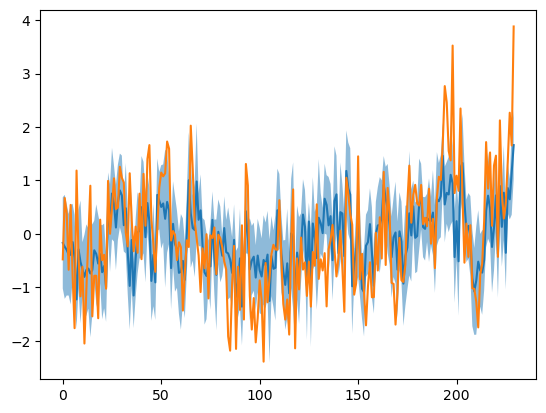

In [13]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

### metrics

In [14]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred,test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_mcmc = evaluate_metrics_multiple(esn_obj=esn_mcmc, y_true = test_set.x.cpu(), test_set = test_set)

Empirical Coverage: 0.785 ± 0.003
Calibration Error:  0.00423 ± 0.00019
mCRPS (Normalized): 0.0829 ± 0.0011
Width: 2.110 ± 0.021


### calibration algorithm

In [15]:
robust_quantiles = np.linspace(0.025,0.975,50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy() 
Y_cal_array = cal_set.x.cpu().numpy()

In [16]:
y_pred_cal = esn_mcmc.predict(cal_set)

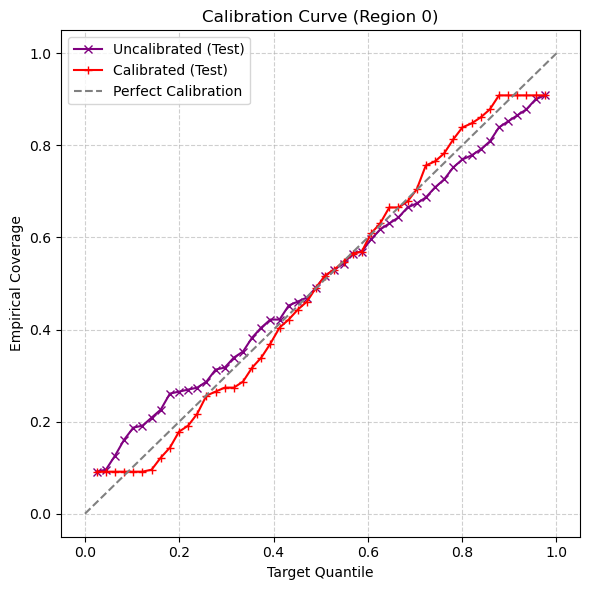

In [17]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
      y_pred_test=y_pred.cpu().numpy(),
      y_pred_val=y_pred_cal.cpu().numpy(),
      Y_test=Y_test_array,       
      Y_val=Y_cal_array,         
      quantiles=robust_quantiles,
      plot_region=0              
 )


In [18]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.3947%
Mean MSCE (Calibrated Test): 0.2639%


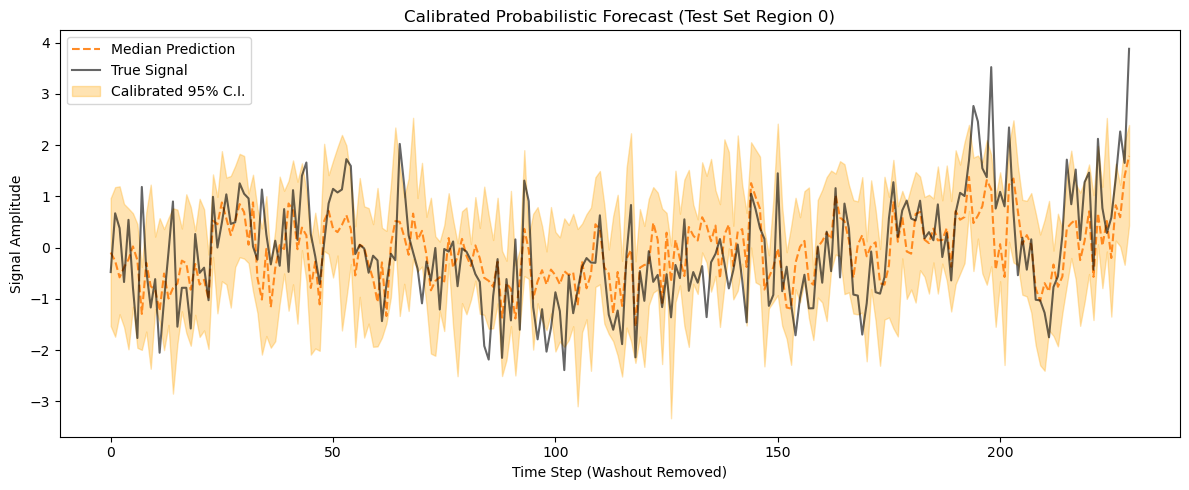

In [19]:
plot_calibrated_test(Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles)

## MCMC with PCA

In [20]:
n_components = num_neurons_real // 2
pca = PCA(n_components)

In [21]:
# move datasets to cpu
train_set = train_set.to(torch.device("cpu"))
cal_set = cal_set.to(torch.device("cpu"))
test_set = test_set.to(torch.device("cpu"))

In [22]:
# fit pca
pca = pca.fit(train_set.states.numpy())

In [23]:
# apply pca to the sets
train_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(train_set.states.numpy())),
    x=train_set.x,
    mu=train_set.mu,
    std=train_set.mu,
    device=device,
)
cal_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(cal_set.states.numpy())),
    x=cal_set.x,
    mu=cal_set.mu,
    std=cal_set.mu,
    device=device,
)
test_pca_set = ESNDataset(
    states=torch.tensor(pca.transform(test_set.states.numpy())),
    x=test_set.x,
    mu=test_set.mu,
    std=test_set.mu,
    device=device,
)

In [24]:
mcmc_pca_model_real = BayesianModel(
    in_features=n_components, out_features=num_features_real
).to(device)

In [25]:
esn_mcmc = ESNMCMC(mcmc_pca_model_real)

In [26]:
# mcmc hyperparameters
warmup_steps = 10
num_samples = 10
num_chains = 1
mp_context = "spawn"

esn_mcmc.run(
    train_pca_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Sample: 100%|██████████| 20/20 [00:01, 12.13it/s, step size=4.73e-03, acc. prob=0.911]


In [27]:
y_pred = esn_mcmc.predict(test_pca_set)
y_pred = y_pred.cpu()

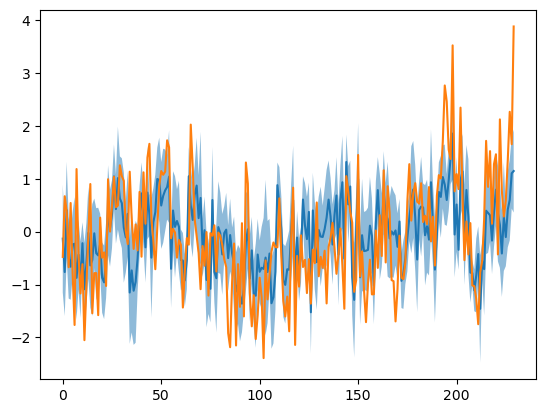

In [28]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

### metrics

In [39]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred,test_pca_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_mcmc_pca = evaluate_metrics_multiple(esn_obj=esn_mcmc, y_true = test_pca_set.x.cpu(), test_set = test_pca_set)

Empirical Coverage: 0.814 ± 0.004
Calibration Error:  0.00250 ± 0.00013
mCRPS (Normalized): 0.0915 ± 0.0010
Width: 2.495 ± 0.029


### calibration

In [30]:
robust_quantiles = np.linspace(0.025,0.975,50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_pca_set.x.cpu().numpy() 
Y_cal_array = cal_pca_set.x.cpu().numpy()

In [31]:
y_pred_cal = esn_mcmc.predict(cal_pca_set)

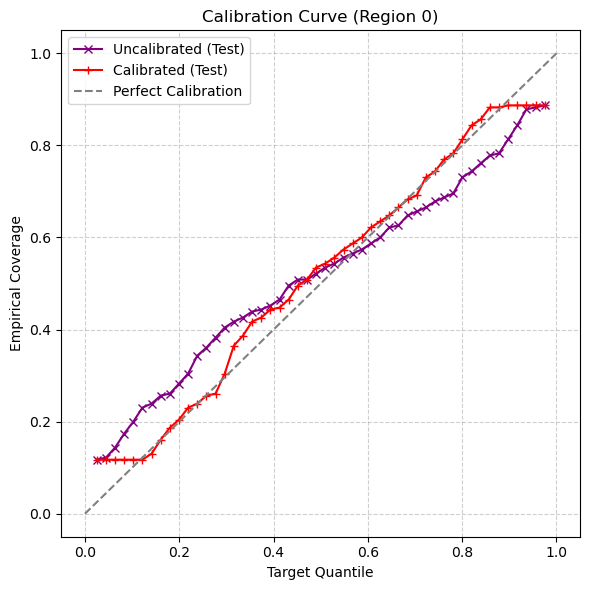

In [32]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
      y_pred_test=y_pred.cpu().numpy(),
      y_pred_val=y_pred_cal.cpu().numpy(),
      Y_test=Y_test_array,       
      Y_val=Y_cal_array,         
      quantiles=robust_quantiles,
      plot_region=0              
 )


In [33]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.3012%
Mean MSCE (Calibrated Test): 0.2449%


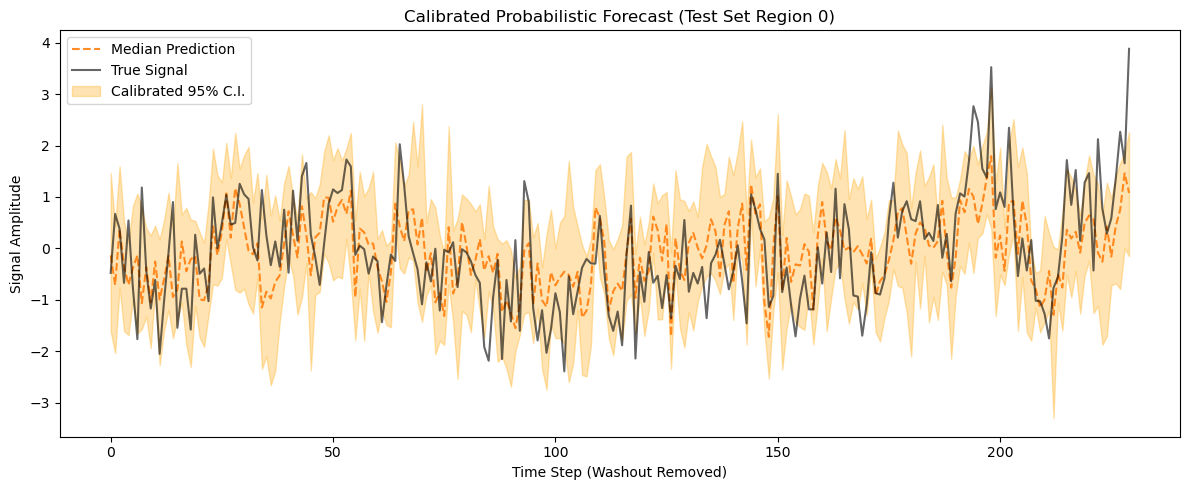

In [34]:
plot_calibrated_test(Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles)

## SVI

In [9]:
# move datasets to gpu
train_set = train_set.to(device)
cal_set = cal_set.to(device)
test_set = test_set.to(device)

In [10]:
svi_model_real = BayesianModel(
    in_features=num_neurons_real, out_features=num_features_real
).to(device)

In [11]:
# Setup Optimizer
LR = 0.001
EPOCHS = 100

optimizer = Adam({"lr": LR})

In [12]:
# PYRO GUIDE

RANK = int(np.sqrt(num_neurons_real))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(svi_model_real, rank=RANK)

In [13]:
esn_var_real = ESNVariational(
    svi_model_real,
    guide,
    optimizer,
)

Training Pyro ESN:   1%|          | 1/100 [00:02<04:49,  2.92s/it, Loss=18508.5381]

Epoch 0 | Total ELBO Loss: 18508.5381


Training Pyro ESN: 100%|██████████| 100/100 [00:54<00:00,  1.85it/s, Loss=921.4301]


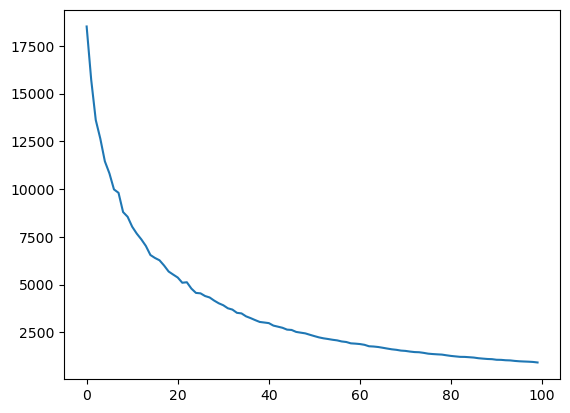

In [ ]:
loss_history = esn_var_real.train(train_set, EPOCHS, batch_size=16, shuffle=True)
plt.plot(loss_history)
plt.show()

In [15]:
y_pred = esn_var_real.predict(test_set)
y_pred = y_pred.cpu()

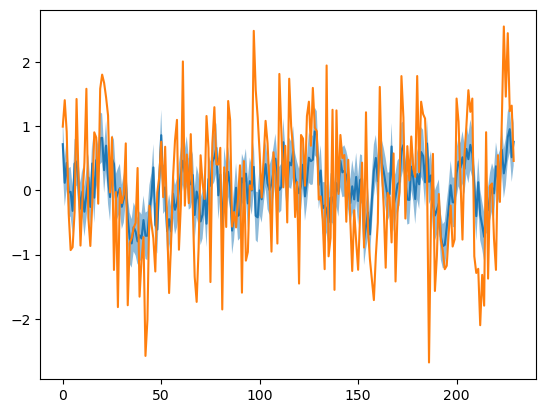

In [16]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

### metrics

In [17]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred,test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
#dict_svi = evaluate_metrics_multiple(esn_obj=esn_var_real, y_true = test_set.x.cpu(), test_set = test_set, n_trials = 5)

Empirical Coverage: 0.619 ± 0.006
Calibration Error:  0.01723 ± 0.00046
mCRPS (Normalized): 0.0937 ± 0.0009
Width: 1.421 ± 0.014


### calibration

In [47]:
robust_quantiles = np.linspace(0.025,0.975,50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy() 
Y_cal_array = cal_set.x.cpu().numpy()

In [48]:
y_pred_cal = esn_var_real.predict(cal_set)

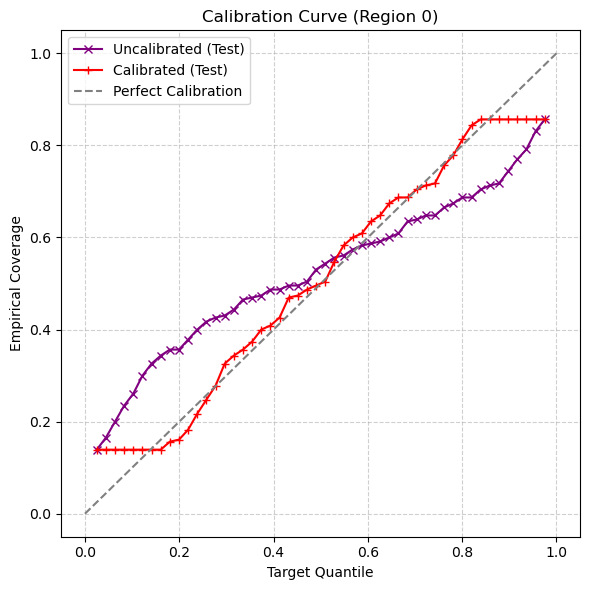

In [49]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
      y_pred_test=y_pred.cpu().numpy(),
      y_pred_val=y_pred_cal.cpu().numpy(),
      Y_test=Y_test_array,       
      Y_val=Y_cal_array,         
      quantiles=robust_quantiles,
      plot_region=0              
 )


In [50]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 1.0509%
Mean MSCE (Calibrated Test): 0.3355%


In [ ]:
plot_calibrated_test(Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles)

## QR

In [63]:
taus = [0.025, 0.25, 0.5, 0.75, 0.975]
# Calculate the exact output size needed (e.g., 119 * 5 = 595)
num_quantiles = len(taus)
out_features = num_features_real * num_quantiles

# Update the linspace to target out_features
num_layers = 3
layer_dims = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_real, out_features, num_layers)
]

# Instantiate the model with the correct dimensions
qr_model_real = MLP(layer_dims, nn.Tanh()).to(device)

# Re-create your loss function and optimizer here...
loss_fn = CheckLoss(taus)
optimizer = torch.optim.Adam(qr_model_real.parameters(), lr=0.001)

# Re-instantiate the wrapper
esn_qr = ESNQR(qr_model_real, optimizer, loss_fn)

Training ESN:   1%|          | 2/200 [00:00<00:35,  5.62it/s, Loss=57.8569]

Epoch 0 | Total Loss: 59.6056


Training ESN:  50%|█████     | 101/200 [00:14<00:12,  7.89it/s, Loss=24.2727]

Epoch 100 | Total Loss: 24.2847


Training ESN: 100%|██████████| 200/200 [00:27<00:00,  7.27it/s, Loss=23.9500]


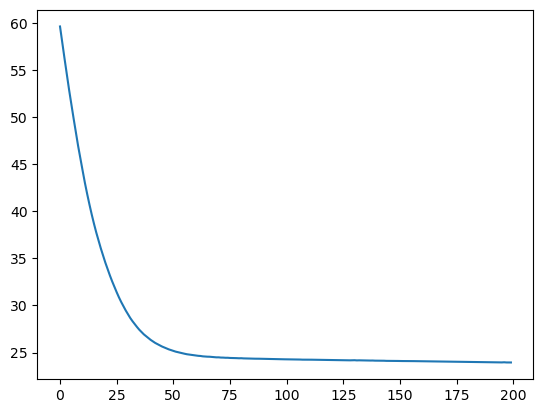

In [64]:
EPOCHS = 200
loss_history = esn_qr.train(train_set, EPOCHS, batch_size=64, shuffle=True)
plt.plot(loss_history)
plt.show()

In [65]:
y_pred = esn_qr.predict(test_set)
y_pred = y_pred.detach().cpu()

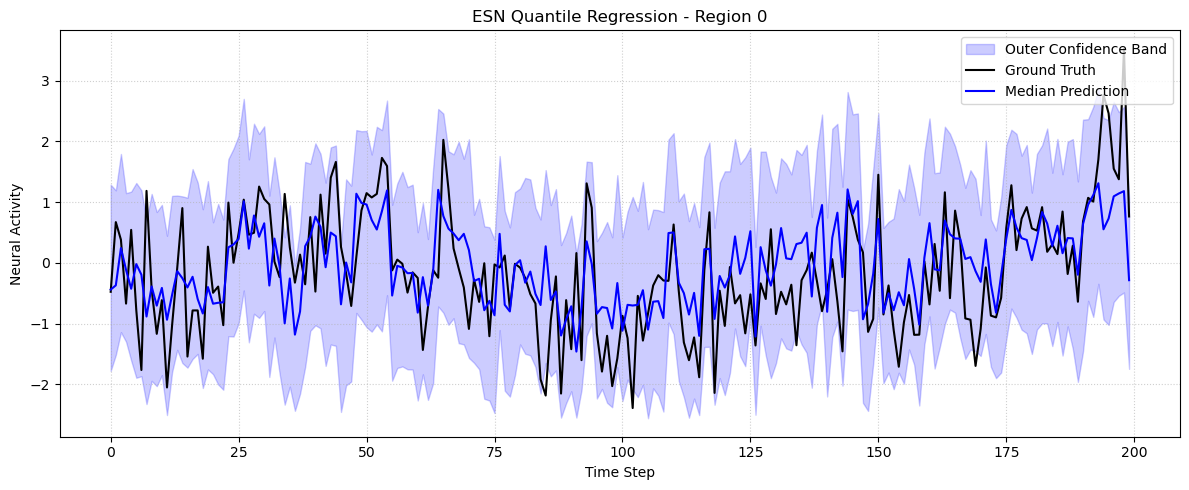

In [66]:
"""
plt.plot(test_set.x[0].cpu())
plt.plot(y_pred[0])
plt.show()
"""
# 1. Convert everything to pure NumPy arrays
y_pred_np = y_pred.numpy()
y_true_np = test_set.x.detach().cpu().numpy()

# 2. Setup plotting parameters
region_idx = 0  # Choose which of the 119 regions to plot (0 to 118)
time_steps = 200  # Plot the first 200 time steps so the chart is readable

# 3. Un-scale the data to original values (Highly Recommended)
mu_val = test_set.mu[region_idx].item()
std_val = test_set.std[region_idx].item()

y_true_region = y_true_np[:time_steps, region_idx]
y_pred_region = y_pred_np[:time_steps, :, region_idx]

# 4. Plotting
plt.figure(figsize=(12, 5))

# Assuming your 5 quantiles are symmetric (e.g., [0.1, 0.3, 0.5, 0.7, 0.9])
# Index 0 = lowest quantile, Index 4 = highest quantile, Index 2 = median

plt.fill_between(
    np.arange(time_steps),
    y_pred_region[:, 0],  # Lower bound
    y_pred_region[:, 4],  # Upper bound
    color="blue",
    alpha=0.2,
    label="Outer Confidence Band",
)


# Plot the Ground Truth
plt.plot(y_true_region, color="black", label="Ground Truth", linewidth=1.5)

# Plot the Median Prediction (50th percentile)
plt.plot(y_pred_region[:, 2], color="blue", linestyle="-", label="Median Prediction")

plt.title(f"ESN Quantile Regression - Region {region_idx}")
plt.xlabel("Time Step")
plt.ylabel("Neural Activity")
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### metrics

In [70]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics_qr(y_pred,test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_qr = evaluate_metrics_multiple(esn_obj=esn_qr, y_true = test_set.x.cpu(), test_set = test_set, 
                                    model_type = "QR", tau_levels = taus)

Empirical Coverage: 0.934 ± 0.002
Calibration Error:  0.00128 ± 0.00012
mCRPS (Normalized): 0.0620 ± 0.0009
Width: 2.827 ± 0.027


## SVSS

In [74]:
ssvs_model_real = SSVS(num_neurons_real, num_features_real).to(device)

In [75]:
esn_mcmc = ESNMCMC(ssvs_model_real)

In [76]:
# mcmc hyperparameters
warmup_steps = 10
num_samples = 10
num_chains = 1
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Sample: 100%|██████████| 20/20 [00:17,  1.17it/s, step size=9.65e-03, acc. prob=0.698]


In [77]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.detach().cpu()

### metrics

In [60]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred,test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_svss = evaluate_metrics_multiple(esn_obj=esn_mcmc, y_true = test_set.x.cpu(), test_set = test_set, n_trials = 5)

Empirical Coverage: 0.813 ± 0.004
Calibration Error:  0.00255 ± 0.00013
mCRPS (Normalized): 0.0892 ± 0.0011
Width: 2.490 ± 0.056


### calibration

In [78]:
robust_quantiles = np.linspace(0.025,0.975,50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy() 
Y_cal_array = cal_set.x.cpu().numpy()

In [79]:
y_pred_cal = esn_mcmc.predict(cal_set)

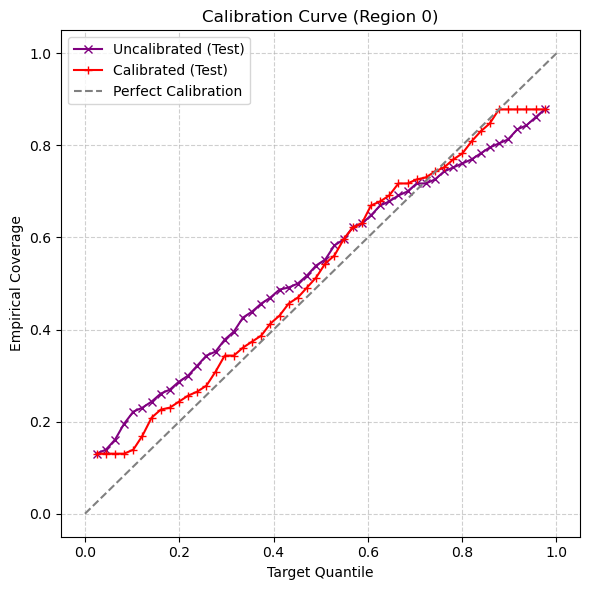

In [80]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
      y_pred_test=y_pred.cpu().numpy(),
      y_pred_val=y_pred_cal.cpu().numpy(),
      Y_test=Y_test_array,       
      Y_val=Y_cal_array,         
      quantiles=robust_quantiles,
      plot_region=0              
 )


In [81]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.6025%
Mean MSCE (Calibrated Test): 0.2236%


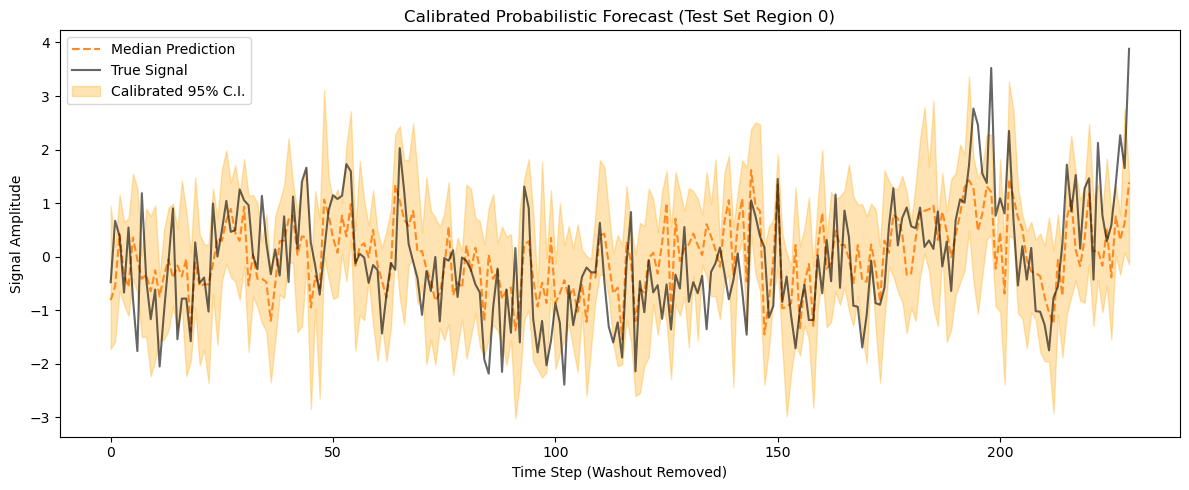

In [82]:
plot_calibrated_test(Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles)

## Bayesian Neural Network

In [88]:
num_layers = 3
layer_sizes = [
    int(layer_size)
    for layer_size in np.linspace(num_neurons_real, num_features_real, num_layers)
]
activation = nn.ELU()
nn_model_real = BayesianNeuralNetwork(layer_sizes, activation).to(device)

In [89]:
esn_mcmc = ESNMCMC(nn_model_real)

In [90]:
# mcmc hyperparameters
warmup_steps = 10
num_samples = 10
num_chains = 1
mp_context = "spawn"

esn_mcmc.run(
    train_set,
    warmup_steps=warmup_steps,
    num_samples=num_samples,
    num_chains=num_chains,
    mp_context=mp_context,
)

Sample: 100%|██████████| 20/20 [00:04,  4.87it/s, step size=2.94e-03, acc. prob=0.875]


In [91]:
y_pred = esn_mcmc.predict(test_set)
y_pred = y_pred.cpu()

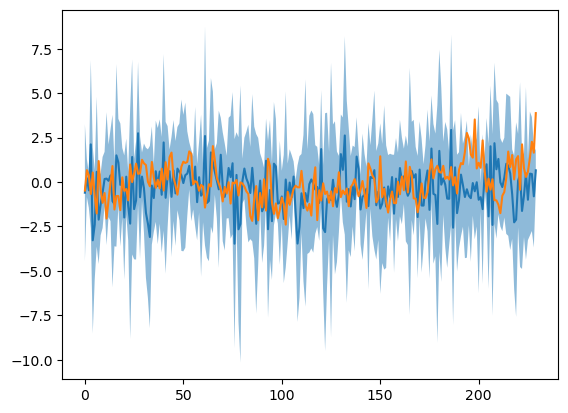

In [92]:
mean = torch.mean(y_pred[:, :, 0], dim=0)
std = torch.std(y_pred[:, :, 0], dim=0)
plt.plot(mean)
plt.fill_between(torch.arange(mean.shape[0]), mean - std, mean + std, alpha=0.5)
plt.plot(test_set.x.cpu()[:, 0])

### metrics

In [67]:
ecov_pr, cal_pr, mcrps_pr, width_pr = evaluate_metrics(y_pred,test_set.x.cpu())
print_metrics(test_set.x.cpu(), ecov_pr, cal_pr, mcrps_pr, width_pr)
dict_bnn = evaluate_metrics_multiple(esn_obj=esn_mcmc, y_true = test_set.x.cpu(), test_set = test_set, n_trials = 5)

Empirical Coverage: 0.876 ± 0.003
Calibration Error:  0.00242 ± 0.00017
mCRPS (Normalized): 0.1005 ± 0.0010
Width: 3.685 ± 0.033


### calibration

In [93]:
robust_quantiles = np.linspace(0.025,0.975,50)
# Extract the ground truth PyTorch tensors and convert to NumPy arrays
Y_test_array = test_set.x.cpu().numpy() 
Y_cal_array = cal_set.x.cpu().numpy()

In [94]:
y_pred_cal = esn_mcmc.predict(cal_set)

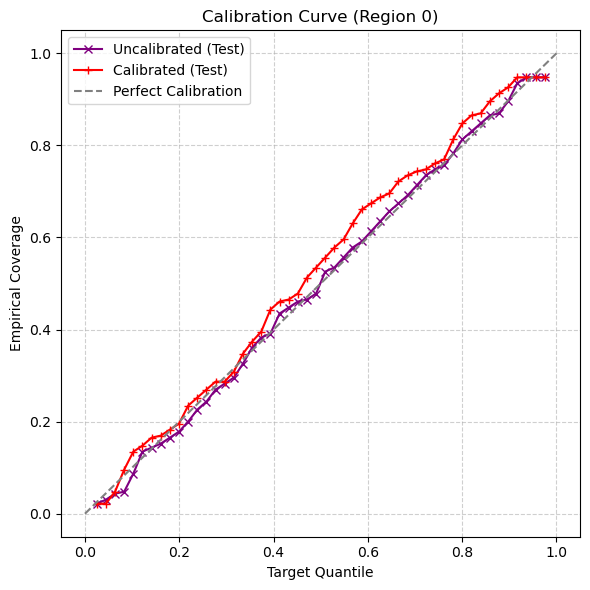

In [95]:
# apply the calibration algorithm
err_uncal, err_cal, adj_quantiles = calibrate(
      y_pred_test=y_pred.cpu().numpy(),
      y_pred_val=y_pred_cal.cpu().numpy(),
      Y_test=Y_test_array,       
      Y_val=Y_cal_array,         
      quantiles=robust_quantiles,
      plot_region=0              
 )


In [96]:
print(f"Mean MSCE (Uncalibrated Test): {np.mean(err_uncal):.4%}")
print(f"Mean MSCE (Calibrated Test): {np.mean(err_cal):.4%}")

Mean MSCE (Uncalibrated Test): 0.3052%
Mean MSCE (Calibrated Test): 0.2551%


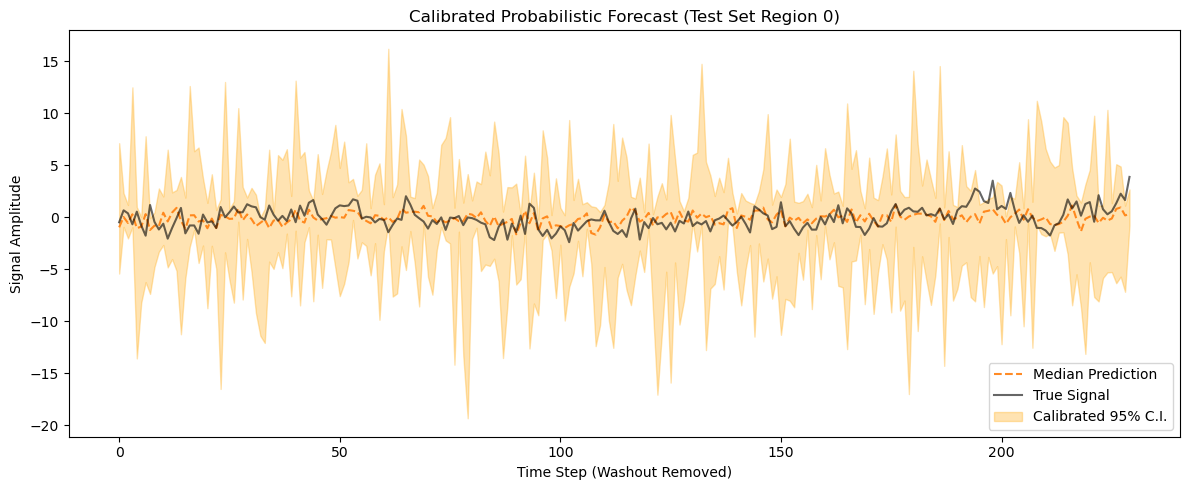

In [97]:
plot_calibrated_test(Y_test_array=Y_test_array, y_pred=y_pred, adj_quantiles=adj_quantiles)

## Radial plot dict

In [68]:
# Pack calculated dictionaries together
all_calculated_results = {
    "MCMC": dict_mcmc,
    "MCMC_PCA": dict_mcmc_pca,
    "SVI": dict_svi,
    "SSVS": dict_svss,
    "QR": dict_qr,
    "BNN": dict_bnn
}

# Run the merger function
dict_radial_plot = combine_metrics_dictionaries(all_calculated_results)

In [69]:
dict_radial_plot

{'Cal': {'MCMC': [0.0036944912280887365,
   0.0038016585167497396,
   0.0036905971355736256,
   0.003674107836559415,
   0.0037054489366710186],
  'MCMC_PCA': [0.002555210143327713,
   0.002546978183090687,
   0.0024578412994742393,
   0.0025873868726193905,
   0.0026526988949626684],
  'SVI': [0.009187371470034122],
  'SSVS': [0.002606029622256756,
   0.002605322515591979,
   0.002515411702916026,
   0.0025908940006047487,
   0.0026112671475857496],
  'QR': [0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009,
   0.0007157115614973009],
  'BNN': [0.002287723822519183,
   0.0024395454674959183,
   0.0024502198211848736,
   0.0025574329774826765,
   0.0024696746841073036]},
 'Cov': {'MCMC': [0.7809280753135681,
   0.7808914184570312,
   0.7823163866996765,
   0.781914472579956,
   0.7796127200126648],
  'MCMC_PCA': [0.8148337602615356,
   0.8108147978782654,
   0.8135185837745667,
   0.8139934539794922,
   0.8111435770988464],
  'SVI': [0.